In [1]:
import matplotlib.pyplot as plt
%matplotlib ipympl

## Calculate CPSDs and statistics

In [2]:
import noisefinder
import numpy as np
import scipy

Just generate two time series with white and `1/f^2` ASD noise spectrum, for this example.\
Calculate the Welch PSD for comparison.

In [3]:
datA = np.cumsum(scipy.stats.norm.rvs(size=100000))
datB = 1000*scipy.stats.norm.rvs(size=100000)
fs = 10 #sampling frequency

#calculate Welch for comparison
CPSD_WOSA  = noisefinder.cpsd.CPSDevaluateWOSA(ts=[datA,datB],nperseg=20000,win=noisefinder.specwindows.BH92,fs=fs,olapmax=0.50,detrend_c=False,optimalolap=True)
PSD_WOSA_datA = CPSD_WOSA.PSD[0]
PSD_WOSA_datB = CPSD_WOSA.PSD[1]

# note, this is equivalent to the following with scipy.signal.welch and scipy.signal.csd, if optimalolap=False.
# in our case, with optimalolap=True, we reduce overlap to maximize data usage
# PSDfA,PSDvA = scipy.signal.welch(datA,fs=10,window='blackmanharris',nperseg=20000)

In [4]:
# define frequency scheme
LPF_frscheme = noisefinder.freqscheme_presets.lpfScheme(Lmax=20000, fmax=None, fs=fs)
CPSD_LPF  = noisefinder.cpsd.CPSDevaluate(ts=[datA,datB],freqscheme=LPF_frscheme)

It saves useful parameters as class attributes (see full list at :class:`noisefinder.CPSDstats`):

In [5]:
CPSD_LPF.CPSD  # The CPSD matrix, at the Fourier frequencies
CPSD_LPF.PSD   # The PSDs of the input time series, at the Fourier frequencies
CPSD_LPF.freqs # The Fourier frequencies
CPSD_LPF.navs  # The number of averaged periodograms, useful for confidence interval evaluation
CPSD_LPF.cohere # Coherencies
CPSD_LPF.Ls # The stretch length (number of samples) for CPSD evaluation at each frequency.

array([20000, 20000, 12000,  7200,  4319,  2592,  1555,   933,   559,
         335,   201,   120,    72,    43,    26])

Calculate the PSD posterior confidence interval (for instance, at 0.68 - 1 sigma confidence level).

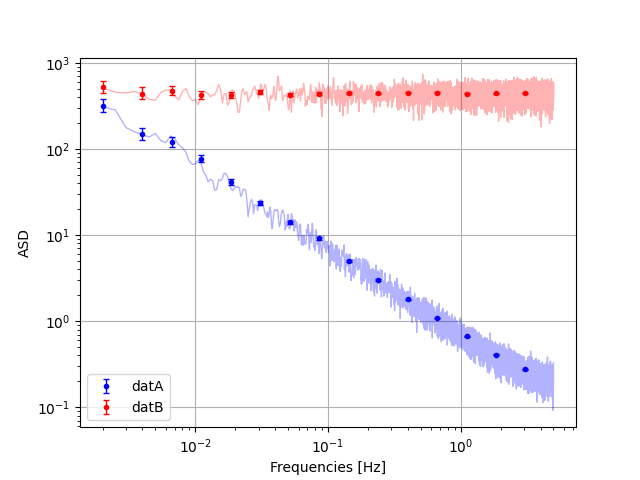

In [6]:
#extract confidence intervals
ASD_LPF_CI_datA = noisefinder.cpsd.stats.ASDposterior_qnt(CPSD_LPF,tsidx=0,q=[(1-0.68)/2,0.50,((1+0.68)/2)])
ASD_LPF_CI_datB = noisefinder.cpsd.stats.ASDposterior_qnt(CPSD_LPF,tsidx=1,q=[(1-0.68)/2,0.50,((1+0.68)/2)])

fig,ax=plt.subplots()
ax.loglog(CPSD_WOSA.freqs[4:],np.sqrt(PSD_WOSA_datA[4:]),lw=1, c='b', alpha=0.3)
ax.loglog(CPSD_WOSA.freqs[4:],np.sqrt(PSD_WOSA_datB[4:]),lw=1, c='r', alpha=0.3)

ax.errorbar(CPSD_LPF.freqs,
            ASD_LPF_CI_datA[1,:],
            yerr = [ASD_LPF_CI_datA[1,:]-ASD_LPF_CI_datA[0,:],
                    ASD_LPF_CI_datA[2,:]-ASD_LPF_CI_datA[1,:]],
            linestyle='',capsize=2.5,lw=1,c='b',fmt='.',label='datA')
ax.errorbar(CPSD_LPF.freqs,
            ASD_LPF_CI_datB[1,:],
            yerr = [ASD_LPF_CI_datB[1,:]-ASD_LPF_CI_datB[0,:],
                    ASD_LPF_CI_datB[2,:]-ASD_LPF_CI_datB[1,:]],
            linestyle='',capsize=2.5,lw=1,c='r',fmt='.',label='datB')
ax.grid(); ax.set_xlabel('Frequencies [Hz]'); ax.set_ylabel('ASD'); ax.legend()
plt.show()

fig.savefig("_images/cpsdeval.png",dpi=300)

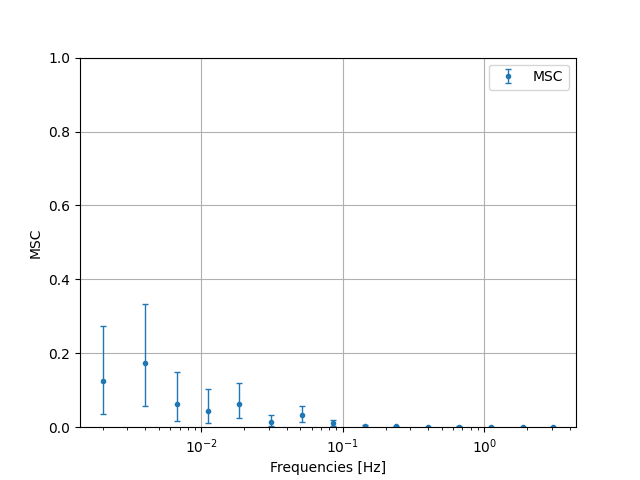

In [7]:
#same goes for MSC between two ts and R2

CPSD_LPF_MSC = noisefinder.cpsd.stats.MSCposterior_qnt(CPSD_LPF,idx1=0,idx2=1,q=[(1-0.68)/2,0.50,((1+0.68)/2)])

fig,ax=plt.subplots()
ax.errorbar(x=CPSD_LPF.freqs,
            y=CPSD_LPF_MSC[:,1],
            yerr = [CPSD_LPF_MSC[:,1]-CPSD_LPF_MSC[:,0],CPSD_LPF_MSC[:,2]-CPSD_LPF_MSC[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C0',fmt='.',label='MSC')
ax.grid(); ax.set_ylim([0,1]); ax.set_xscale('log'); ax.legend()
ax.set_xlabel('Frequencies [Hz]'); ax.set_ylabel('MSC');
plt.show()

fig.savefig("_images/cpsdevalMSC.png",dpi=300)

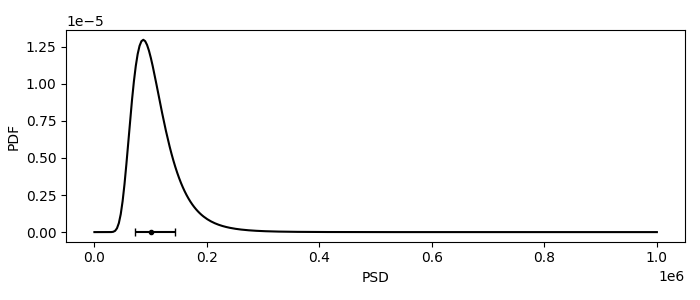

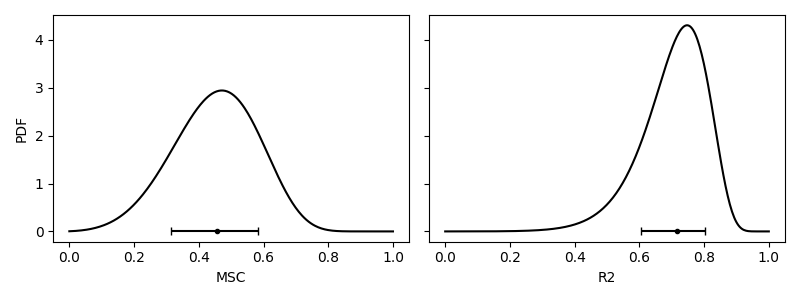

In [12]:
# PSD posterior distribution, as frozen scipy.stats, of the PSD posterior 
PSD_datA_distrib = noisefinder.cpsd.stats_methods.PSDposterior_dist_onebin(CPSD_LPF.PSD[0][0], navs=CPSD_LPF.navs[0]) 
PSD_datA_f0_rvs = PSD_datA_distrib.rvs(size=100000)

# PSD pdf, evaluated at given points
PSDth_axis = np.linspace(0,1e6,300)
PSDpdf = noisefinder.cpsd.stats_methods.PSDposterior_onebin(CPSD_LPF.PSD[0][0], navs=CPSD_LPF.navs[0],PSDth=PSDth_axis)
PSDCI  = noisefinder.cpsd.stats.PSDposterior_qnt(CPSD_LPF, tsidx=0, q=[(1-0.68)/2,0.50,((1+0.68)/2)])

MSCth=np.linspace(0,1,300)
MSCexp=0.5; navs=14;
MSCpdf = noisefinder.cpsd.stats_methods.MSCposterior_onebin(MSCth=MSCth,MSCexp=MSCexp,navs=navs) # MSC posterior evaluated on the MSCth axis 
MSCCI = noisefinder.cpsd.stats_methods.MSCposterior_qnt_onebin(MSCexp=MSCexp,navs=navs,q=[(1-0.68)/2,0.50,((1+0.68)/2)]) # MSC posterior confidence interval at given confidence level

R2th=np.linspace(0,1,300)
R2exp=0.8
R2pdf = noisefinder.cpsd.stats_methods.R2posterior_onebin(R2th=R2th,R2exp=R2exp,navs=navs,p=4) # R2 posterior, evaluated on the R2th axis. p is the number of timeseries
R2CI = noisefinder.cpsd.stats_methods.R2posterior_qnt_onebin(R2exp=R2exp,navs=navs,p=4,q=[(1-0.68)/2,0.50,((1+0.68)/2)]) # R2 posterior confidence interval at given confidence level

fig,ax=plt.subplots(figsize=(7,3))
ax.plot(PSDth_axis,PSDpdf,c='k')
ax.errorbar(x=[PSDCI[1][0]], y=0, xerr = [[PSDCI[1][0]-PSDCI[0][0]],[PSDCI[2][0]-PSDCI[1][0]]],
            fmt='.', color='black', capsize=3, linestyle='None')
ax.set_xlabel('PSD'); ax.set_ylabel('PDF')
fig.tight_layout()
fig.savefig("_images/PSD_pdf.png",dpi=300)

fig,ax=plt.subplots(1,2,figsize=(8,3),sharey=True,sharex=True)
ax[0].plot(MSCth,MSCpdf,c='k')
ax[0].errorbar(x=[MSCCI[1]],y=0, xerr = [[MSCCI[1]-MSCCI[0]],[MSCCI[2]-MSCCI[1]]],
               fmt='.', color='black', capsize=3, linestyle='None')
ax[0].set_xlabel('MSC'); ax[0].set_ylabel('PDF')

ax[1].plot(R2th,R2pdf,c='k')
ax[1].errorbar(x=[R2CI[1]],y=0, xerr = [[R2CI[1]-R2CI[0]],[R2CI[2]-R2CI[1]]],
               fmt='.', color='black', capsize=3, linestyle='None')
ax[1].set_xlabel('R2'); #ax[1].set_ylabel('PDF')
fig.tight_layout()
fig.savefig("_images/MSC_R2_pdf.png",dpi=300)



In [ ]:
def custom_freqscheme(fs): # more user-defined params
    BH92 = noisefinder.specwindows.BH92 #user-defined
    Ls = np.array([20000, 12000, 7200]) #user-defined, with external method
    dft_idxs = np.array([8,8,8]) #user-defined, with external method
    return noisefinder.FreqScheme(
        fs=fs,
        olapmax=0.50,
        dft_idxs=dft_idxs,
        Ls=Ls,
        win=BH92,
        optimalolap=True
    )